## What the letters stand for:
- S: Susceptible individuals
- I: Infected individuals
- R: Recovered individuals
- N: Total population (S + I + R)
- β: Transmission rate
- γ: Recovery rate
- R<sub>0</sub>: Basic Reproduction Number

## Formulas:
- $dS/dt = -\beta \cdot S \cdot (I/N)$
    - $I/N$: The probability that a random person you interact with is sick
    - $\beta \cdot (I/N)$: The rate at which one susceptible person gets successfully infected.
    - $S \cdot [\beta \cdot (I/N)]$: the total number of new infections
- $dI/dt = \beta \cdot S \cdot I / N - \gamma \cdot I$
- $dR/dt = \gamma \cdot I$
- $R_{0} = \beta / \gamma$
    - $R_{0} > 1$: Disease spread
    - $R_{0} = 1$: Threshold
    - $R_{0} < 1$: Disease extinction

## ODE vs. Agent-Based Model
*ODE: Ordinary Differential Equations
### ODE Models
- It looks at the population as a whole and mathematically moves continuous fractions of people between large compartments based on average rates.
- Strengths: Incredibly fast
- Weaknesses: Ignores individuality.
### Agent-Based Models
- You give each individual agent specific attributes.
- Strengths: Highly realistic
- Weakness: Requires immense processing power and highly complex coding logic.

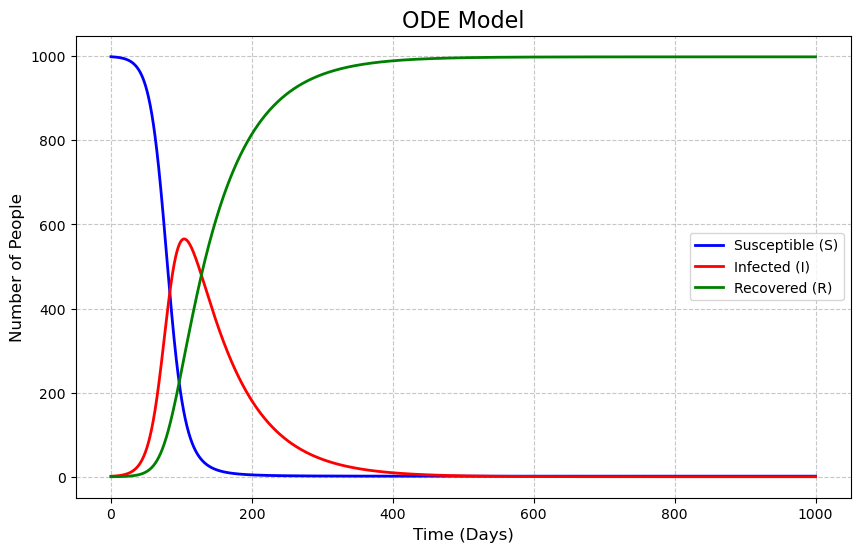

In [2]:
import numpy as np, matplotlib.pyplot as plt

# --- Set initial parameters ---
N = 1000; I0 = 1.0
S, I, R = N-I0, I0, 0.0
beta, gamma = 0.1, 0.015
Tarr = []; Sarr = []; Iarr = []; Rarr = []
T = 1000.0 # Total duration of the simulation in days
dt = 0.01

def deriv(S, I, beta, gamma, N):
    return -beta*S*I/N, beta*S*I/N-gamma*I, gamma*I

# --- Modified Euler method ---
for t in np.arange(0, T, dt):
    Tarr.append(t); Sarr.append(S); Iarr.append(I); Rarr.append(R)
    dS1, dI1, dR1 = deriv(S, I, beta, gamma, N)
    Stem = S + dt * dS1
    Item = I + dt * dI1
    Rtem = R + dt * dR1
    dS2, dI2, dR2 = deriv(Stem, Item, beta, gamma, N)
    S += 0.5 * dt * (dS1 + dS2)
    I += 0.5 * dt * (dI1 + dI2)
    R += 0.5 * dt * (dR1 + dR2)

# --- Visualization ---
plt.figure(figsize=(10, 6)) # Graph size

# Plot the three curves for S, I, R
plt.plot(Tarr, Sarr, label='Susceptible (S)', color='blue', linewidth=2)
plt.plot(Tarr, Iarr, label='Infected (I)', color='red', linewidth=2)
plt.plot(Tarr, Rarr, label='Recovered (R)', color='green', linewidth=2)

# Add labels and styling
plt.title("ODE Model", fontsize=16)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Number of People", fontsize=12)
plt.legend(loc='best') # Show legend
plt.grid(True, linestyle='--', alpha=0.7) # Add background grid

plt.show()

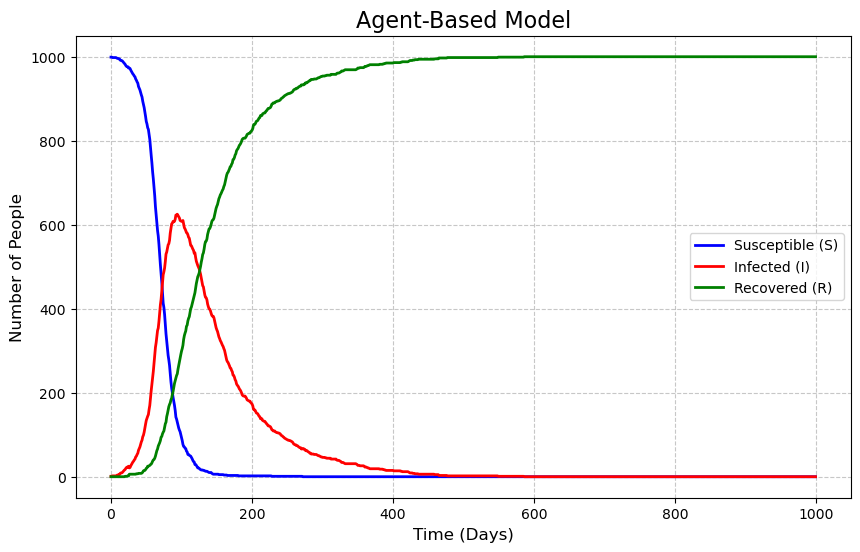

In [3]:
# --- Set Initial Epidemiological Parameters ---
N = 1000; I0 = 1
beta = 0.1; gamma = 0.015
T = 1000

# --- Initialize the Population Array ---
# Health states: 0 = Susceptible (Healthy), 1 = Infected (Sick), -1 = Recovered (Immune)
state = np.zeros(N, dtype=int) # Create an array of 1000 people.
# Randomly pick 'I0' number of people from the population to be Patient Zero (Set state to 1)
state[np.random.randint(N, size=I0)] = 1

# Lists to track the daily size of each compartment for the final graph
Tarr = []; Sarr = []; Iarr = []; Rarr = []

# --- Run the Daily Simulation Loop ---
for t in range(T):
    # Create a snapshot of today's statuses.
    statenew = state.copy() # Deep copy

    # Find the exact ID numbers (indices) of everyone who is currently infected or recovered
    Ilist = np.where(state == 1)[0]
    Rlist = np.where(state==-1)[0]

    # Count the total number of people in each compartment today
    I = len(Ilist); R = len(Rlist); S = N - I - R

    # Record today's numbers into our tracking lists
    Tarr.append(t); Sarr.append(S); Iarr.append(I); Rarr.append(R)

    # --- 4. Daily Interactions (The Core Agent-Based Logic) ---
    # Loop through every single infected person one by one
    for infected_person in Ilist:
        randomly_bumped_person = np.random.randint(N)
        if state[randomly_bumped_person] == 0:
            # The infected person to interact with exactly one single random person per day.
            if np.random.rand() < beta:
                statenew[randomly_bumped_person] = 1
        if np.random.rand() < gamma:
            statenew[infected_person] = -1
    
    state = statenew

# --- Visualization ---
plt.figure(figsize=(10, 6)) # Graph size

# Plot the three curves for S, I, R
plt.plot(Tarr, Sarr, label='Susceptible (S)', color='blue', linewidth=2)
plt.plot(Tarr, Iarr, label='Infected (I)', color='red', linewidth=2)
plt.plot(Tarr, Rarr, label='Recovered (R)', color='green', linewidth=2)

# Add labels and styling
plt.title("Agent-Based Model", fontsize=16)
plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Number of People", fontsize=12)
plt.legend(loc='best') # Show legend
plt.grid(True, linestyle='--', alpha=0.7) # Add background grid

plt.show()

## Introduction of Spatial Structure
- Grid Model: An agent occupies a specific cell of grid.
- Continuous Euclidean Space
- Network Model

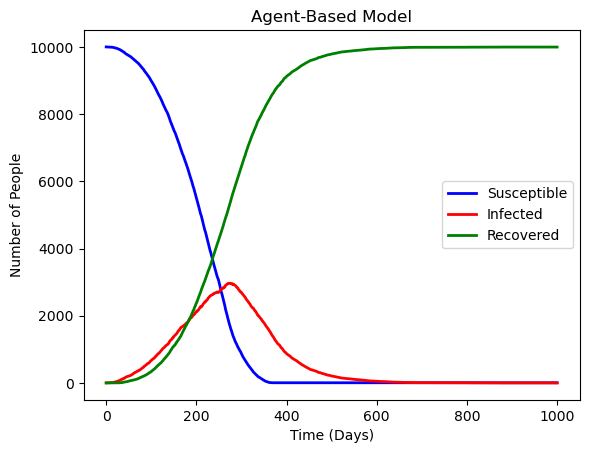

In [4]:
import numpy as np, matplotlib.pyplot as plt

# --- Set Initial Parameters ---
L = 100 # Grid size, Total population^1/2
I0 = 1
beta = 0.1; gamma = 0.015
T = 1000 # Days of simulation

# --- Initialization ---
N = L**2 # Total population
grid = np.zeros((L, L), dtype=int)

# Randomly assign infected state
initial_infected_indices = np.random.choice(N, I0, replace=False)
grid.flat[initial_infected_indices] = 1

Tarr = [0]; Sarr = [N-I0]; Iarr = [I0]; Rarr = [0]

# --- Main Logic ---
for t in range(T):
    next_grid = grid.copy()
    infected_lines = np.argwhere(grid == 1)

    # If the infection dies out completely, stop the simulation early
    if len(infected_lines) == 0:
        for remaining_t in range(t, T):
            Sarr.append(Sarr[-1])
            Iarr.append(Iarr[-1])
            Rarr.append(Rarr[-1])
            Tarr.append(remaining_t +1)
        break

    # Process status updates for each infected individual
    for i in infected_lines:
        r, c = i[0], i[1]

        # Define periodic (toroidal) boundary conditions for 4-way neighbors
        neighbors = [
            (r, (c + 1) % L),
            ((r + 1) % L, c),
            (r, (c - 1) % L),
            ((r - 1) % L, c)
        ]
    
        # Transmission phase: Infect susceptible neighbors based on beta
        for nr, nc in neighbors:
            if grid[nr, nc] == 0:
                if np.random.rand() < beta:
                    next_grid[nr, nc] = 1

        # Recovery phase: Infected individual transitions to Recovered (2) based on gamma
        if np.random.rand() < gamma:
            next_grid[r, c] = 2
    grid = next_grid

    # Calculate and store populations for the current time step
    S = np.sum(grid == 0); I = np.sum(grid == 1); R = np.sum(grid == 2)
    Sarr.append(S); Iarr.append(I); Rarr.append(R)
    Tarr.append(t + 1)

# --- Visualization ---
plt.plot(Tarr, Sarr, label="Susceptible", color="blue", linewidth=2)
plt.plot(Tarr, Iarr, label="Infected", color="red", linewidth=2)
plt.plot(Tarr, Rarr, label="Recovered", color="green", linewidth=2)

plt.title("Agent-Based Model")
plt.xlabel("Time (Days)")
plt.ylabel("Number of People")
plt.legend(loc="best")

plt.show()